<a href="https://colab.research.google.com/github/Mridener/IN498-Capstone-in-Analytics/blob/main/Unit5/IN498_MakaylaRidener_Unit5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GitHub Repository

A GitHub repository was used to track project progress and store all assignment files.

In [17]:
%cd /content/IN498-Capstone-in-Analytics

!git add Unit5/IN498_MakaylaRidener_Unit5.ipynb
!git commit -m "Completed Unit 5 notebook and visualizations"
!git push origin main

/content/IN498-Capstone-in-Analytics
[main 7560576] Completed Unit 5 notebook and visualizations
 1 file changed, 328 insertions(+)
 create mode 100644 Unit5/IN498_MakaylaRidener_Unit5.ipynb
fatal: could not read Username for 'https://github.com': No such device or address


# Data Visualization Code

The final CSV file was read into a data frame and used to create the required visualizations and predictive plots.

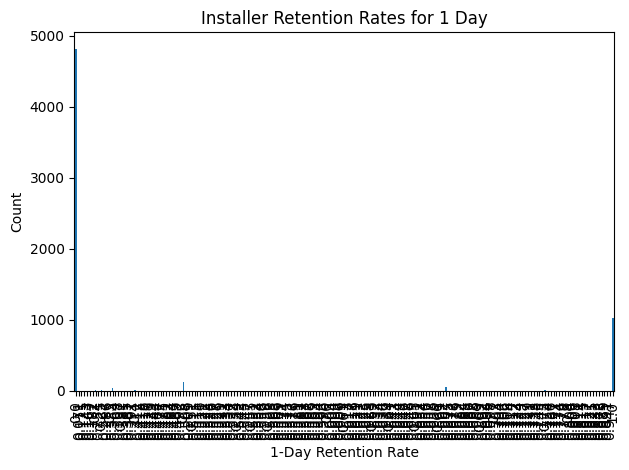

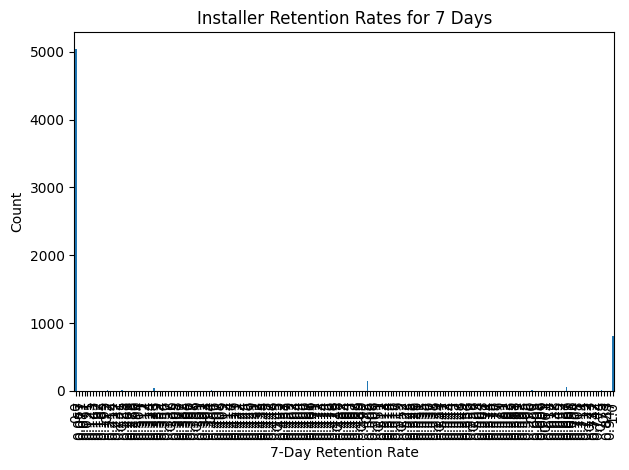

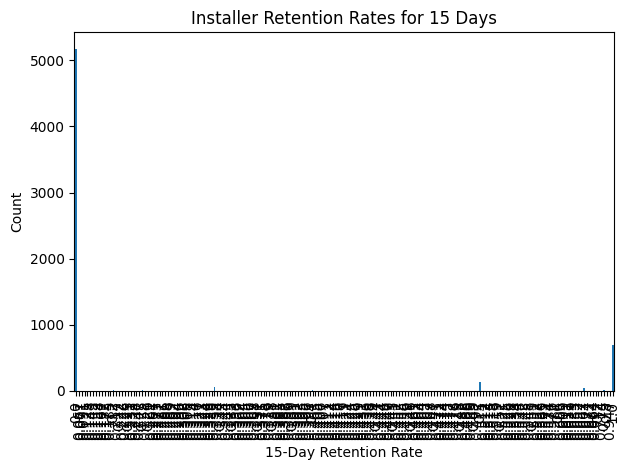

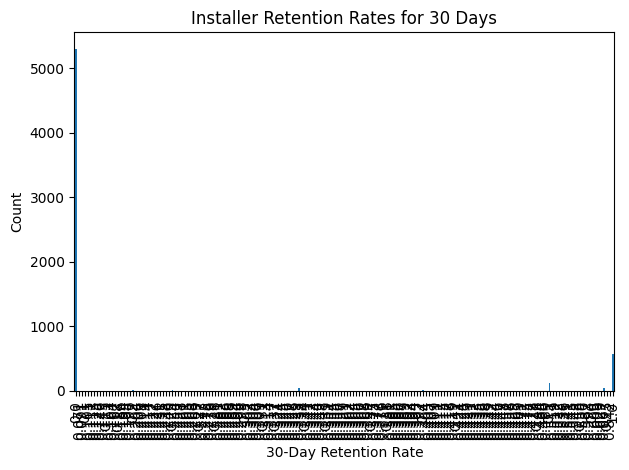

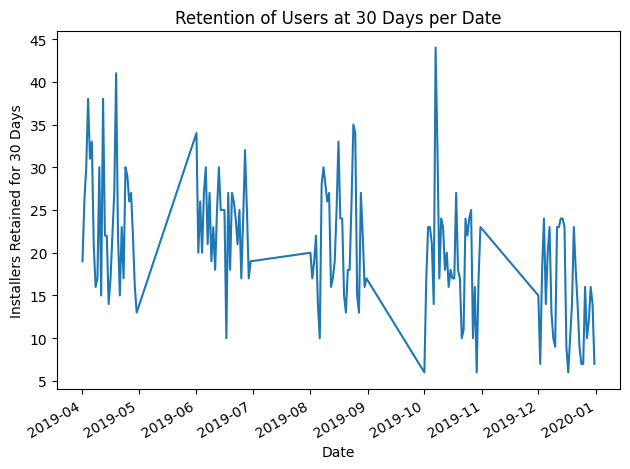

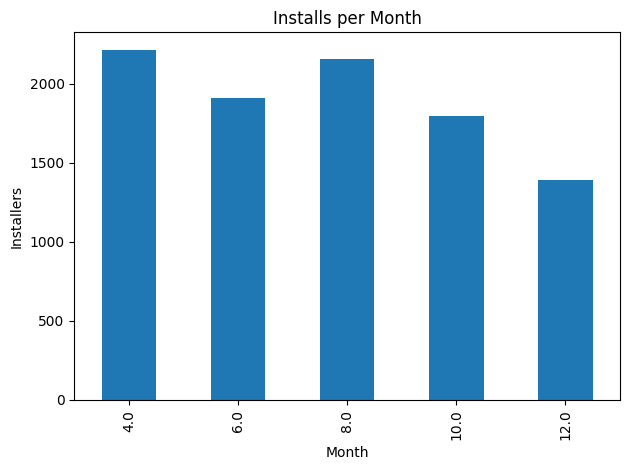

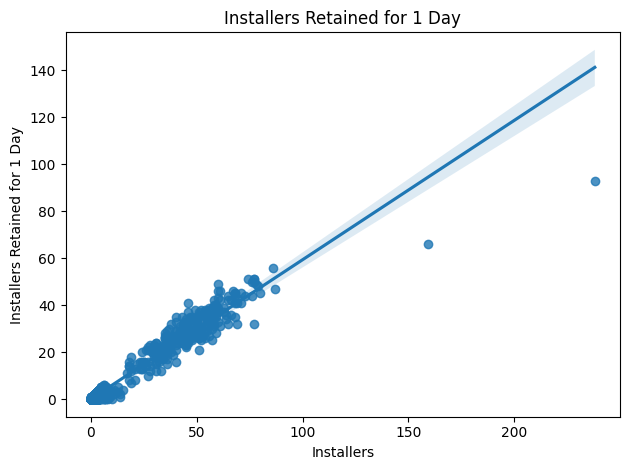

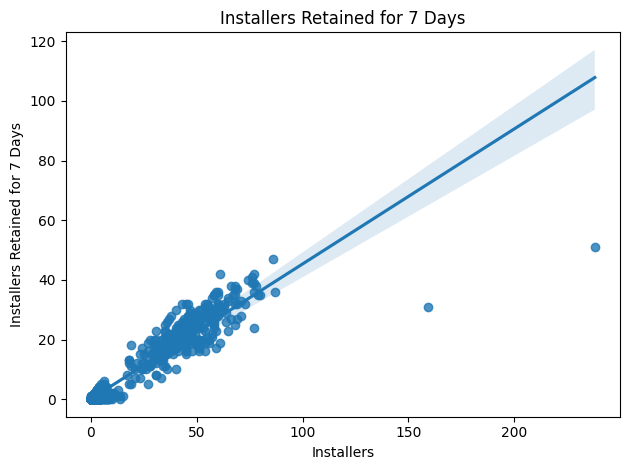

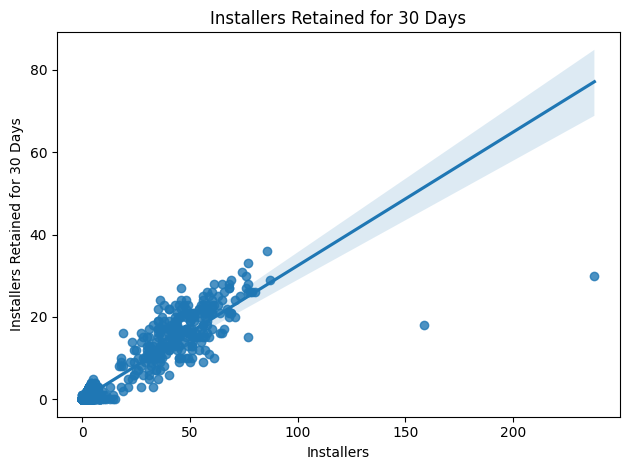

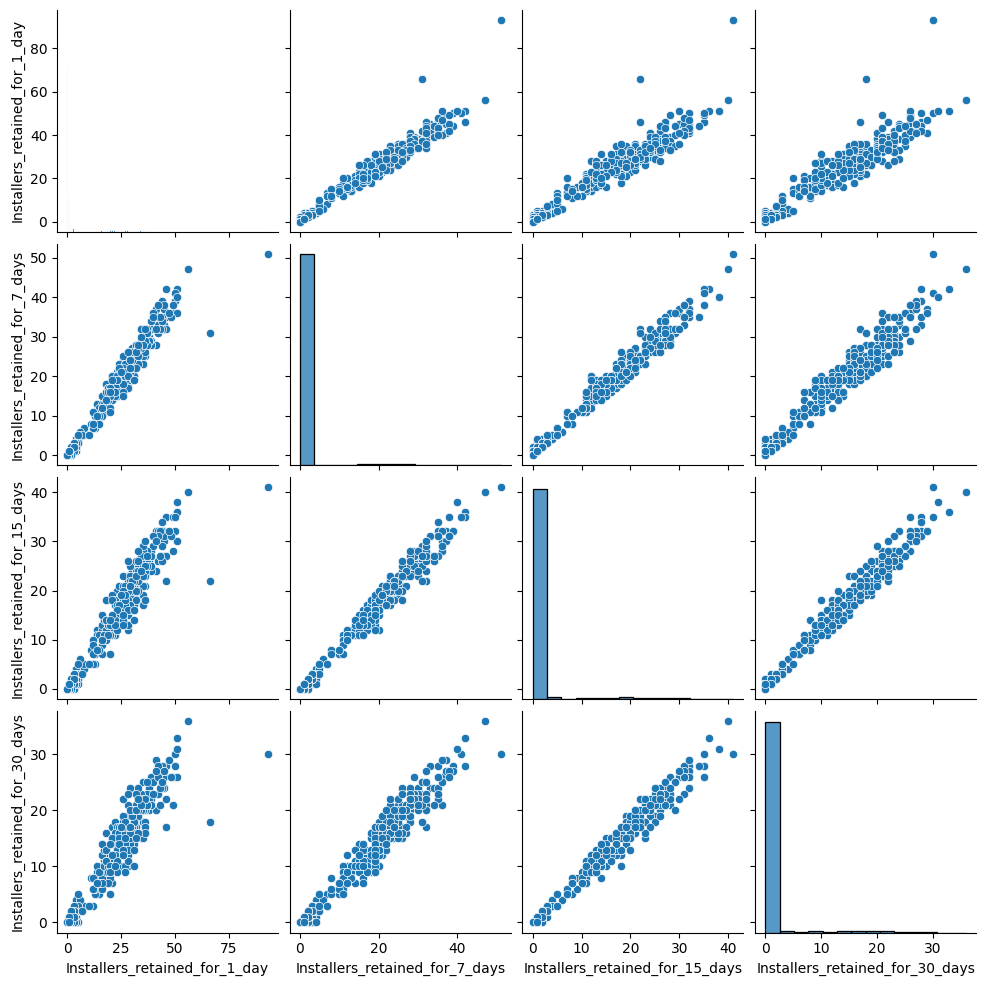

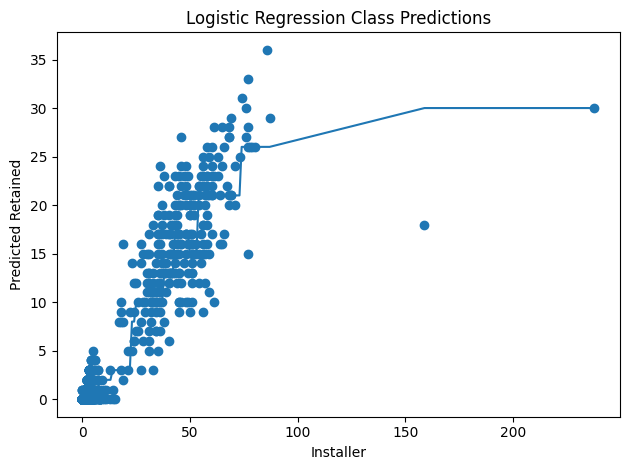

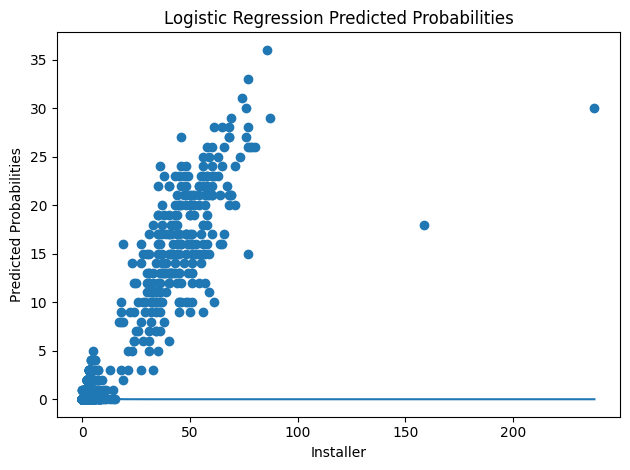

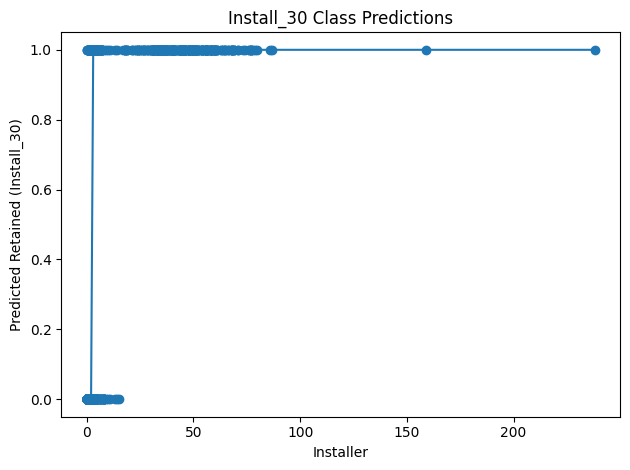

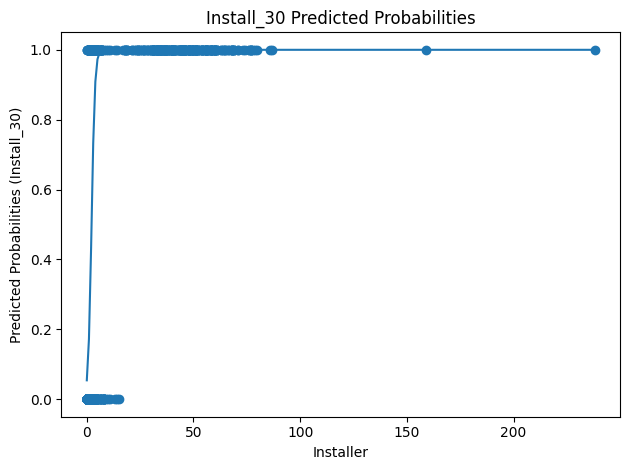

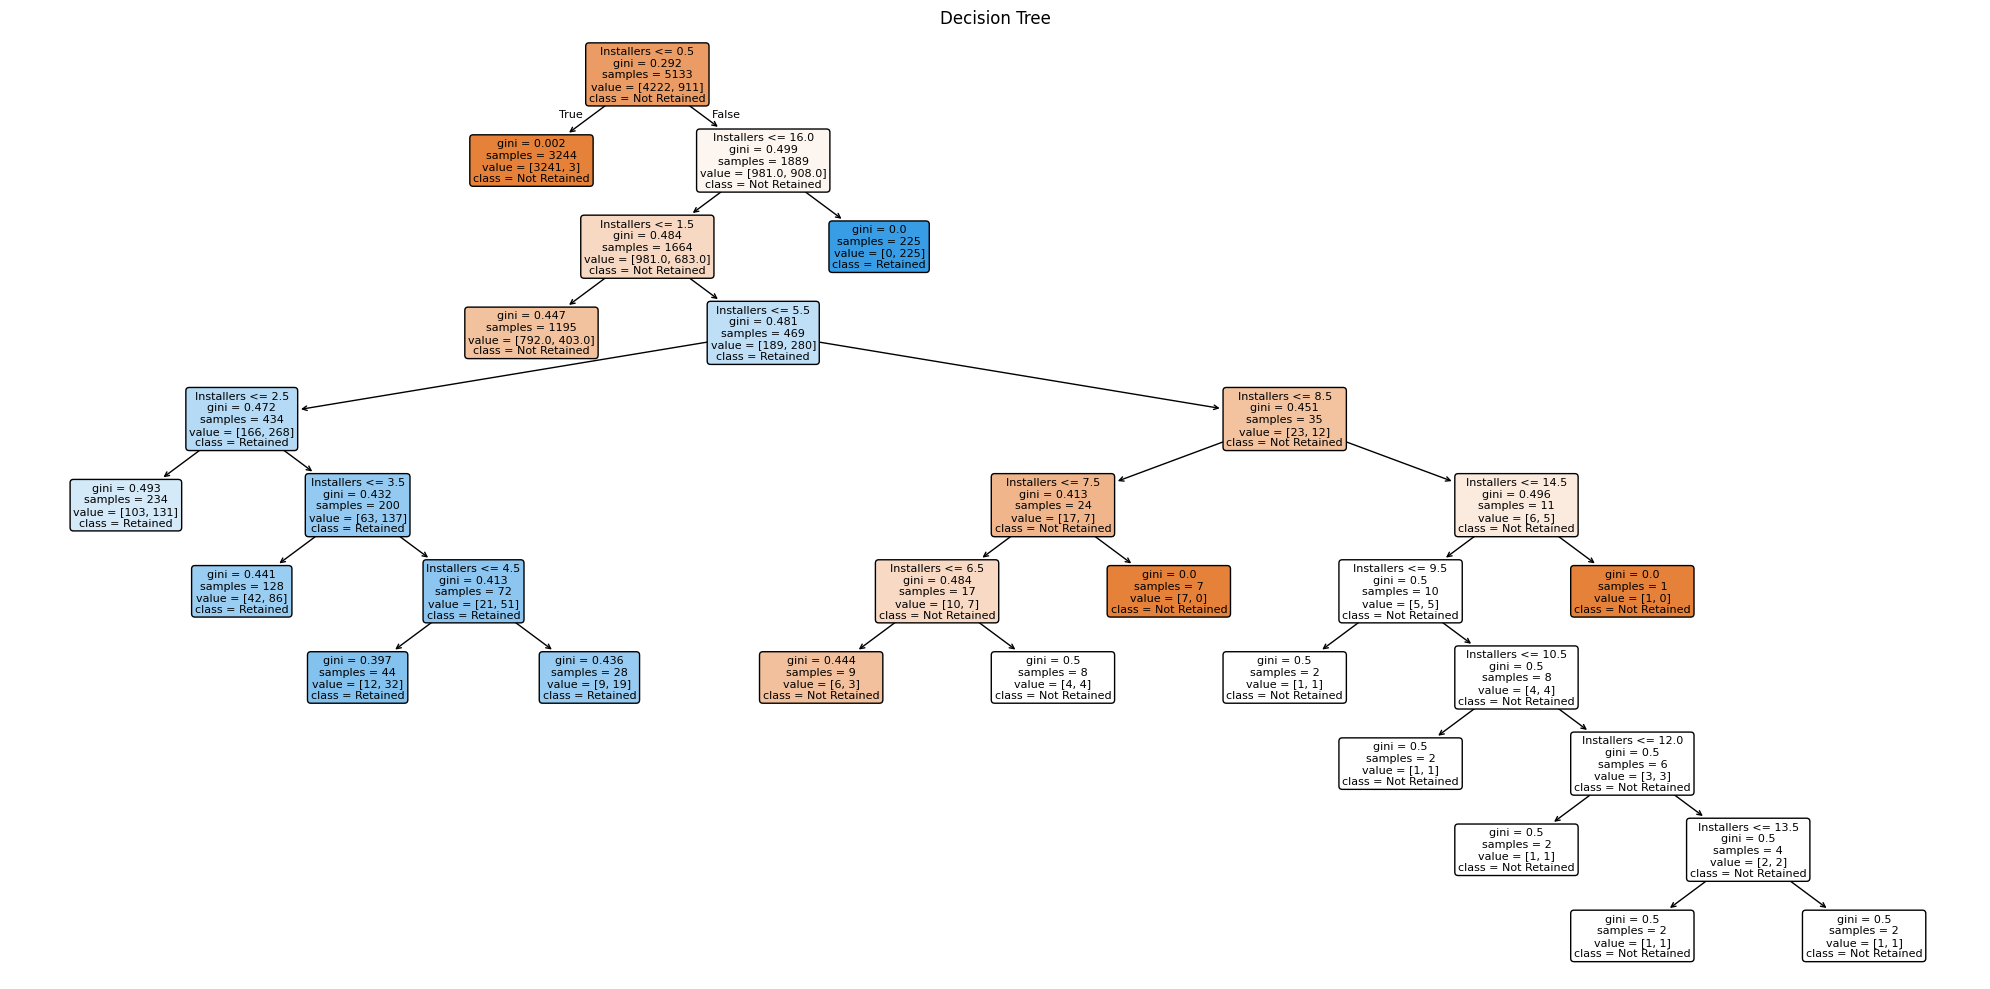

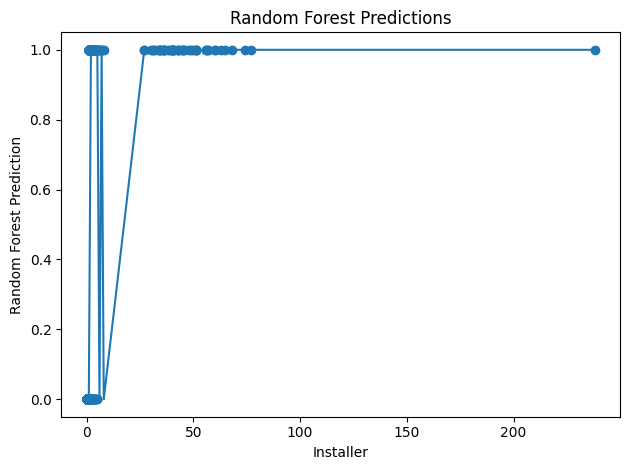

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn import metrics
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree

#Ignoring warnings
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")



#Widen the column display
pd.set_option('max_colwidth',500)

#Read data into a DataFrame using these columns
##"Date","Package_Name","Country","Store_Listing_Visitors",
##"Installers","Visitor-to-Installer_conversion_rate",
##"Installers_retained_for_1_day","Installer-to-1_day_retention_rate",
##"Installers_retained_for_7_days","Installer-to-7_days_retention_rate",
##"Installers_retained_for_15_days","Installer-to-15_days_retention_rate",
##"Installers_retained_for_30_days","Installer-to-30_days_retention_rate"
col_names = ["Date",
             "Package_Name",
             "Country",
             "Store_Listing_Visitors",
             "Installers",
             "Visitor-to-Installer_conversion_rate",
             "Installers_retained_for_1_day",
             "Installer-to-1_day_retention_rate",
             "Installers_retained_for_7_days",
             "Installer-to-7_days_retention_rate",
             "Installers_retained_for_15_days",
             "Installer-to-15_days_retention_rate",
             "Installers_retained_for_30_days",
             "Installer-to-30_days_retention_rate"]

data = pd.read_csv("retained_installers_final.csv")

########### EXPLORE THE ORIGINAL DATA SET #######################

#Plot the installer retention rates for 1 day using a bar chart
data["Installer-to-1_day_retention_rate"].value_counts().sort_index().plot(
    kind="bar",
    title="Installer Retention Rates for 1 Day"
)
plt.xlabel("1-Day Retention Rate")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("BarChart_1DayRetention.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Plot the installer retention rates for 7 days using a bar chart
data["Installer-to-7_days_retention_rate"].value_counts().sort_index().plot(
    kind="bar",
    title="Installer Retention Rates for 7 Days"
)
plt.xlabel("7-Day Retention Rate")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("BarChart_7DayRetention.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Plot the installer retention rates for 15 days using a bar chart
data["Installer-to-15_days_retention_rate"].value_counts().sort_index().plot(
    kind="bar",
    title="Installer Retention Rates for 15 Days"
)
plt.xlabel("15-Day Retention Rate")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("BarChart_15DayRetention.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Plot the installer retention rates for 30 days using a bar chart
data["Installer-to-30_days_retention_rate"].value_counts().sort_index().plot(
    kind="bar",
    title="Installer Retention Rates for 30 Days"
)
plt.xlabel("30-Day Retention Rate")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("BarChart_30DayRetention.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Plot the retention of users at 30 days per date using a line chart
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

retention_by_date = data.groupby("Date")[
    "Installers_retained_for_30_days"
].sum()

retention_by_date.plot(
    kind="line",
    title="Retention of Users at 30 Days per Date"
)
plt.xlabel("Date")
plt.ylabel("Installers Retained for 30 Days")
plt.tight_layout()
plt.savefig("LineChart_30DayRetentionByDate.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Add a month column by converting the Date column for month only
data['Month'] = pd.DatetimeIndex(data['Date']).month

#Plot the installs per month using a bar chart
installs_by_month = data.groupby("Month")["Installers"].sum()

installs_by_month.plot(
    kind="bar",
    title="Installs per Month"
)
plt.xlabel("Month")
plt.ylabel("Installers")
plt.tight_layout()
plt.savefig("BarChart_InstallsPerMonth.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


########### EARLY SEABORN PLOTS #######################

#Seaborn simple regression plot of installers retained for 1 day
sns.regplot(
    data=data,
    x="Installers",
    y="Installers_retained_for_1_day"
)
plt.title("Installers Retained for 1 Day")
plt.xlabel("Installers")
plt.ylabel("Installers Retained for 1 Day")
plt.tight_layout()
plt.savefig("Regression_1Day.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Seaborn simple regression plot of installers retained for 7 day
sns.regplot(
    data=data,
    x="Installers",
    y="Installers_retained_for_7_days"
)
plt.title("Installers Retained for 7 Days")
plt.xlabel("Installers")
plt.ylabel("Installers Retained for 7 Days")
plt.tight_layout()
plt.savefig("Regression_7Day.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Seaborn simple regression plot of installers retained for 30 day
sns.regplot(
    data=data,
    x="Installers",
    y="Installers_retained_for_30_days"
)
plt.title("Installers Retained for 30 Days")
plt.xlabel("Installers")
plt.ylabel("Installers Retained for 30 Days")
plt.tight_layout()
plt.savefig("Regression_30Day.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


############ FIX MISSING DATA #######################

#Replace NaN with 0 for Installers_retained_for_30_days
data["Installers_retained_for_30_days"] = (
    data["Installers_retained_for_30_days"].fillna(0)
)

############ SEABORN PLOT AFTER FIXING MISSING DATA #######################

#Seaborn pairplot for installers retained for 1, 7, 15, and 30 days
retention_columns = ["Installers_retained_for_1_day",
                     "Installers_retained_for_7_days",
                     "Installers_retained_for_15_days",
                     "Installers_retained_for_30_days"]

pairplot = sns.pairplot(data[retention_columns])
pairplot.savefig("PairPlot_Retention.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


########### LOGISTIC REGRESSION #######################

#Get logistic regression model
logreg = LogisticRegression(max_iter=5000)

#Set feature_cols to Installers column data only
feature_cols = ['Installers']

#Set X to feature_cols
X = data[feature_cols]

#Set y to installer retained for 30 days
y = data.Installers_retained_for_30_days

#Fit X and y to logistic regression model
logreg.fit(X, y)

#Predict classes using X and save as a variable called assorted_pred_class
assorted_pred_class = logreg.predict(X)


#Plot the predictions in a scatter plot using
#Scatter uses data.Installers and data.Installers_retained_for_30_days
#X label of Installer
#y label of predicted retained
#Plot using data.Installer and the prediction results (assorted_pred_class) on X
sort_order = np.argsort(data.Installers.to_numpy())

plt.scatter(
    data.Installers,
    data.Installers_retained_for_30_days
)
plt.plot(
    data.Installers.to_numpy()[sort_order],
    assorted_pred_class[sort_order]
)
plt.xlabel("Installer")
plt.ylabel("Predicted Retained")
plt.title("Logistic Regression Class Predictions")
plt.tight_layout()
plt.savefig("Scatter_LogisticClassPrediction.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Get the predicted probabilites of class 1
#Save as a variable called assorted_pred_prob
class_index = np.where(logreg.classes_ == 1)[0][0]
assorted_pred_prob = logreg.predict_proba(X)[:, class_index]


#Scatter plot the predicted probabilities
#Scatter uses data.Installers and data.Installers_retained_for_30_days
#X label of Installer
#y label of predicted probabilities
#Plot using data.Installer and the probability results (assorted_pred_prob) on X
plt.scatter(
    data.Installers,
    data.Installers_retained_for_30_days
)
plt.plot(
    data.Installers.to_numpy()[sort_order],
    assorted_pred_prob[sort_order]
)
plt.xlabel("Installer")
plt.ylabel("Predicted Probabilities")
plt.title("Logistic Regression Predicted Probabilities")
plt.tight_layout()
plt.savefig("Scatter_LogisticProbability.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#################################### INSTALL_30 ##########################################

#Add a new column for installers retained for 30 days
#Call the new column Install_30.
#  If greater than 0, put 1, if 0, put 0
data["Install_30"] = np.where(
    data["Installers_retained_for_30_days"] > 0,
    1,
    0
)


########### LOGISTIC REGRESSION #######################

#Perform logistic regression using Install_30 column for y
# X = Installers column
logreg = LogisticRegression(max_iter=5000)
feature_cols = ['Installers']
X = data[feature_cols]
y = data.Install_30

#Fit X and y for logistic regression
logreg.fit(X, y)


#Predict on X and capture the result to assorted_pred_class
assorted_pred_class = logreg.predict(X)


#Plot the class predictions
#Scatter uses data.Intsallers and data.Install_30
#Plot uses data.Installers and assorted_pred_class
#X label is Installer
#Y label is Predicted Retained (Install_30)
sort_order = np.argsort(data.Installers.to_numpy())

plt.scatter(
    data.Installers,
    data.Install_30
)
plt.plot(
    data.Installers.to_numpy()[sort_order],
    assorted_pred_class[sort_order]
)
plt.xlabel("Installer")
plt.ylabel("Predicted Retained (Install_30)")
plt.title("Install_30 Class Predictions")
plt.tight_layout()
plt.savefig("Scatter_Install30Prediction.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#Get the predicted probabilites of class 1 and save to assorted_pred_prob
assorted_pred_prob = logreg.predict_proba(X)[:, 1]


#Plot the predicted probabilities
#Scatter uses data.Intsallers and data.Install_30
#Plot uses data.Installers and assorted_pred_prob
#X label is Installer
#Y label is Predicted Probabilities (Install_30)
plt.scatter(
    data.Installers,
    data.Install_30
)
plt.plot(
    data.Installers.to_numpy()[sort_order],
    assorted_pred_prob[sort_order]
)
plt.xlabel("Installer")
plt.ylabel("Predicted Probabilities (Install_30)")
plt.title("Install_30 Predicted Probabilities")
plt.tight_layout()
plt.savefig("Scatter_Install30Probability.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


########### DECISION TREE #######################

#Train/test split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#Build a decision tree model
dt = DecisionTreeClassifier(random_state=1)

#Fit the tree using X_train and y_train
dt.fit(X_train, y_train)


#Plot the decision tree
plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt,
    feature_names=["Installers"],
    class_names=["Not Retained", "Retained"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree")
plt.tight_layout()
plt.savefig("DecisionTree.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


########### RANDOM FOREST #######################

#Build a random forest tree model
# n_estimators = 1000
rf=RandomForestClassifier(n_estimators=1000)

#Fit the random tree model with X_train and y_train
rf.fit(X_train,y_train)

#Get the predicitons using X_test and save to rf_probs
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)


#Plot the random forest predictions using rf_preds
sort_order = np.argsort(X_test["Installers"].to_numpy())

plt.scatter(
    X_test["Installers"],
    y_test
)
plt.plot(
    X_test["Installers"].to_numpy()[sort_order],
    rf_preds[sort_order]
)
plt.xlabel("Installer")
plt.ylabel("Random Forest Prediction")
plt.title("Random Forest Predictions")
plt.tight_layout()
plt.savefig("RandomForestPredictions.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Data Visualization Results